In [52]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

In [53]:
words = open('/Users/raghav/Downloads/names.txt').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [54]:
len(words)

32033

In [55]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [56]:
#dataset

block_size = 3
X = []
Y = []

for w in words:
    context = [0] * block_size
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        context = context[1:] + [ix]

X = torch.tensor(X)
Y = torch.tensor(Y)

In [57]:
X.shape , X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [58]:
C = torch.randn(27,2)
C[5]

tensor([-0.3986,  0.7710])

In [59]:
C[X].shape

torch.Size([228146, 3, 2])

In [60]:
X[13,2].item()

1

In [61]:
C[X]

tensor([[[-0.1834,  1.0331],
         [-0.1834,  1.0331],
         [-0.1834,  1.0331]],

        [[-0.1834,  1.0331],
         [-0.1834,  1.0331],
         [-0.3986,  0.7710]],

        [[-0.1834,  1.0331],
         [-0.3986,  0.7710],
         [ 1.0949,  0.0545]],

        ...,

        [[ 1.9448, -2.2671],
         [ 1.9448, -2.2671],
         [ 1.2179, -0.2096]],

        [[ 1.9448, -2.2671],
         [ 1.2179, -0.2096],
         [ 1.9448, -2.2671]],

        [[ 1.2179, -0.2096],
         [ 1.9448, -2.2671],
         [-1.2776,  0.5814]]])

In [62]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [63]:
W1 = torch.randn(6,100)
b1 = torch.randn(100)

In [64]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [65]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,2),generator = g)
W1 = torch.randn((6,300),generator = g)
b1 = torch.randn(300, generator = g)
W2 = torch.randn((300,27),generator = g)
b2 = torch.randn(27,generator = g)
parameters = [C,W1,b1,W2,b2]

In [66]:
for p in parameters:
    p.requires_grad = True

In [67]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre 

In [68]:
lri = []
lossi = []


for i in range(10000):
    #mini batch construct
    ix = torch.randint(0,X.shape[0],(32,))
    #forward pass
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Y[ix])
 
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.1
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    #lossi.append(loss.item())


print(loss.item())

2.485132932662964


In [69]:
#train split, #dev/validation split ,#test split

#building the dataset 

def build_dataset(words):
    block_size = 3
    X,Y = [],[]
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape)
    print(Y.shape)
    return X,Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,Ytr = build_dataset(words[:n1])
Xdev,Ydev = build_dataset(words[n1:n2])
Xte,Yte = build_dataset(words[n2:])

torch.Size([182625, 3])
torch.Size([182625])
torch.Size([22655, 3])
torch.Size([22655])
torch.Size([22866, 3])
torch.Size([22866])


In [70]:
C = torch.randn(27,2)

In [99]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,20),generator = g)
W1 = torch.randn((60,400),generator = g) * 0.1
b1 = torch.randn(400, generator = g) * 0.01
W2 = torch.randn((400,27),generator = g) * 0.01
b2 = torch.randn(27,generator = g) * 0
parameters = [C,W1,b1,W2,b2]

In [100]:
for p in parameters:
    p.requires_grad = True

In [101]:
sum(p.nelement() for p in parameters)

35767

In [102]:
lre = torch.linspace(-3,0,1000)
lrs = 10 ** lre 

In [103]:
lri = []
lossi = []
stepi = []

In [104]:

for i in range(200000):
    #mini batch construct
    ix = torch.randint(0,Xtr.shape[0],(32,))
    #forward pass
    emb = C[Xtr[ix]]
    h = torch.tanh(emb.view(-1,60) @ W1 + b1)
    logits = h @ W2 + b2
    # counts = logits.exp()
    # prob = counts / counts.sum(1, keepdims = True)
    # loss = -prob[torch.arange(32),Y].log().mean()
    loss = F.cross_entropy(logits,Ytr[ix])
 
    #backward pass
    for p in parameters:
        p.grad = None
    loss.backward()
    
    #update
    # lr = lrs[i]
    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    #track stats
    # lri.append(lre[i])
    stepi.append(i)
    lossi.append(loss.log10().item())


#print(loss.item())

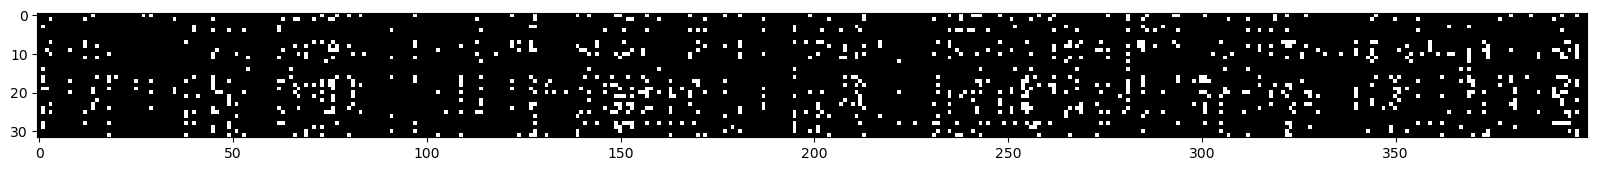

In [105]:
plt.figure(figsize=(20,10))
plt.imshow(h.abs() > 0.99,cmap = 'gray', interpolation = 'nearest')

(array([4658.,  230.,  140.,  103.,   95.,   78.,   69.,   51.,   53.,
          39.,   27.,   43.,   33.,   46.,   39.,   45.,   30.,   64.,
          42.,   45.,   40.,   57.,   53.,   52.,   51.,   67.,   60.,
          52.,   66.,   31.,   30.,   50.,   44.,   36.,   33.,   26.,
          30.,   34.,   48.,   46.,   49.,   58.,   55.,   58.,   86.,
          87.,  120.,  134.,  211., 5106.]),
 array([-1.  , -0.96, -0.92, -0.88, -0.84, -0.8 , -0.76, -0.72, -0.68,
        -0.64, -0.6 , -0.56, -0.52, -0.48, -0.44, -0.4 , -0.36, -0.32,
        -0.28, -0.24, -0.2 , -0.16, -0.12, -0.08, -0.04,  0.  ,  0.04,
         0.08,  0.12,  0.16,  0.2 ,  0.24,  0.28,  0.32,  0.36,  0.4 ,
         0.44,  0.48,  0.52,  0.56,  0.6 ,  0.64,  0.68,  0.72,  0.76,
         0.8 ,  0.84,  0.88,  0.92,  0.96,  1.  ]),
 <BarContainer object of 50 artists>)

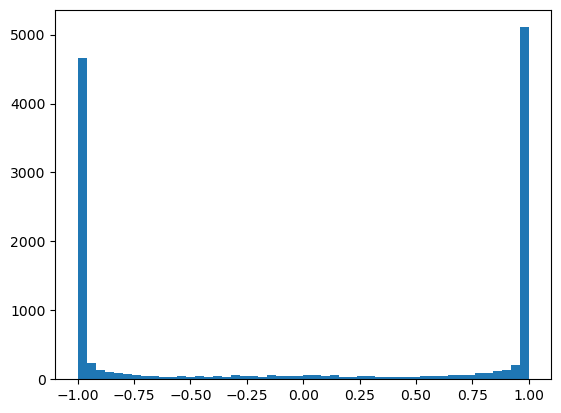

In [97]:
plt.hist(h.view(-1).tolist(),50)

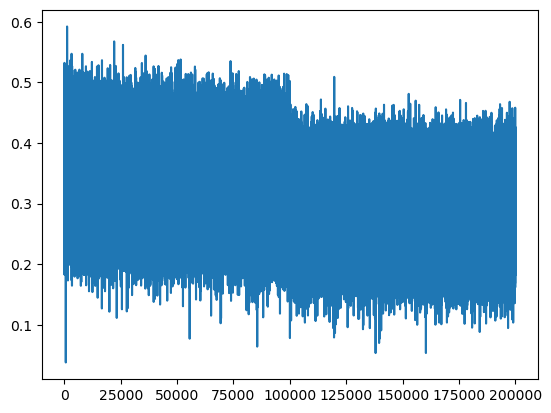

In [98]:
plt.plot(stepi,lossi)

In [89]:
emb = C[Xtr]
h = torch.tanh(emb.view(-1,60) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ytr)
loss

tensor(2.0055, grad_fn=<NllLossBackward0>)

In [90]:
emb = C[Xdev]
h = torch.tanh(emb.view(-1,60) @ W1 + b1)
logits = h @ W2 + b2 
loss = F.cross_entropy(logits,Ydev)
loss

tensor(2.1194, grad_fn=<NllLossBackward0>)

In [91]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]
        h = torch.tanh(emb.view(1,-1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = F.softmax(logits,dim = 1)
        ix = torch.multinomial(probs,num_samples = 1,generator = g).item()
        context = context[1:] + [ix]
        out.append(ix)
        if ix == 0:
            break

    # print(''.join(itos[i]) for i in out))
    print(''.join(itos[i] for i in out))
 

carmahzari.
heriffinleige.
tyrencessa.
jazzuen.
delynn.
jareei.
nellara.
chriha.
kaleigh.
ham.
port.
quint.
sulio.
alianni.
wajerma.
jaryn.
karmellissa.
mel.
edii.
bette.
